In [1]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import mglearn

## Categorical Variables

## One-hot encoding (Dummy Variables)

In [5]:
import pandas as pd

# The file has no headers naming the columns, so we pass header=None
# and provide the column names explicitly in "names"
data = pd.read_csv('adult.csv')

# For illustratio purposes, we only select some of the columns
data = data[['age', 'workclass', 'education', 'gender', 'hours-per-week',
            'occupation', 'income']]

# IPython.display allows nice output formatting within the Jupytr notebook
display(data.head())

,age,workclass,education,gender,hours-per-week,occupation,income
0,25,Private,11th,Male,40,Machine-op-inspct,<=50K
1,38,Private,HS-grad,Male,50,Farming-fishing,<=50K
2,28,Local-gov,Assoc-acdm,Male,40,Protective-serv,>50K
3,44,Private,Some-college,Male,40,Machine-op-inspct,>50K
4,18,?,Some-college,Female,30,?,<=50K


## Checking string-encoded categorical data

In [7]:
print(data.gender.value_counts())

Male      32650
Female    16192
Name: gender, dtype: int64


In [8]:
print('Original features:\n', list(data.columns), '\n')
data_dummies = pd.get_dummies(data)
print('Features after get_dummies:\n', list(data_dummies.columns))

Original features:
 ['age', 'workclass', 'education', 'gender', 'hours-per-week', 'occupation', 'income'] 

Features after get_dummies:
 ['age', 'hours-per-week', 'workclass_?', 'workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'education_10th', 'education_11th', 'education_12th', 'education_1st-4th', 'education_5th-6th', 'education_7th-8th', 'education_9th', 'education_Assoc-acdm', 'education_Assoc-voc', 'education_Bachelors', 'education_Doctorate', 'education_HS-grad', 'education_Masters', 'education_Preschool', 'education_Prof-school', 'education_Some-college', 'gender_Female', 'gender_Male', 'occupation_?', 'occupation_Adm-clerical', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service',

In [11]:
features = data_dummies.loc[:, 'age':'occupation_Transport-moving']

# Extract Numpy arrays
x = features.values
y = data_dummies['income_>50K'].values
print('x.shape: {} y.shape: {}'.format(x.shape, y.shape))

x.shape: (48842, 44) y.shape: (48842,)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(x_train, y_train)
print('Test score: {:.2f}'.format(logreg.score(x_test, y_test)))


Test score: 0.81


## Numbers Can Encode Categoricals

In [15]:
# create a DataFrame with an integer feature and a categorical string feature
demo_df = pd.DataFrame({'Integer Feature': [0, 1, 2, 1],
                       'Categoricals Feature': ['socks', 'fox', 'socks', 'box']})
display(demo_df)

,Integer Feature,Categoricals Feature
0,0,socks
1,1,fox
2,2,socks
3,1,box


In [16]:
pd.get_dummies(demo_df)

,Integer Feature,Categoricals Feature_box,Categoricals Feature_fox,Categoricals Feature_socks
0,0,0,0,1
1,1,0,1,0
2,2,0,0,1
3,1,1,0,0


## Binning, Discretization, Linear Models, and Tree

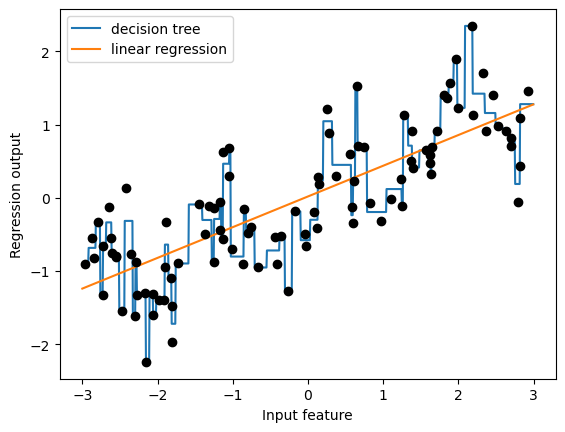

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

x, y = mglearn.datasets.make_wave(n_samples=100)
line = np.linspace(-3, 3, 1000, endpoint=False).reshape(-1, 1)

reg = DecisionTreeRegressor(min_samples_split=3).fit(x, y)
plt.plot(line, reg.predict(line), label='decision tree')

reg = LinearRegression().fit(x, y)
plt.plot(line, reg.predict(line), label='linear regression')

plt.plot(x[:, 0], y, 'o', c='k')
plt.ylabel('Regression output')
plt.xlabel('Input feature')
plt.legend()

In [25]:
bins = np.linspace(-3, 3, 11)
print('bins: {}'.format(bins))

bins: [-3.  -2.4 -1.8 -1.2 -0.6  0.   0.6  1.2  1.8  2.4  3. ]


In [27]:
which_bin = np.digitize(x, bins=bins)
print('\nData points:\n', x[:5])
print('\nBin membershio for data points:\n', which_bin[:5])


Data points:
 [[-0.75275929]
 [ 2.70428584]
 [ 1.39196365]
 [ 0.59195091]
 [-2.06388816]]

Bin membershio for data points:
 [[ 4]
 [10]
 [ 8]
 [ 6]
 [ 2]]


In [30]:
from sklearn.preprocessing import OneHotEncoder

# transform using the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# encoder.fit finds the unique values that appear in which_bin
encoder.fit(which_bin)

# we were stay in paris
# transfrom creates the one-hot encoding
x_binned = encoder.transform(which_bin)
print(x_binned[:5])

[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [31]:
print('x_binned.shape: {}'.format(x_binned.shape))

x_binned.shape: (100, 10)


Text(0.5, 0, 'Input feature')

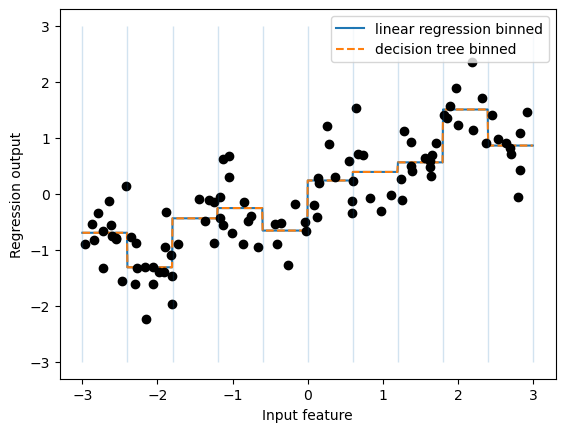

In [34]:
line_binned = encoder.transform(np.digitize(line, bins=bins))

reg = LinearRegression().fit(x_binned, y)
plt.plot(line, reg.predict(line_binned), label='linear regression binned')

reg = DecisionTreeRegressor(min_samples_split=3).fit(x_binned, y)
plt.plot(line, reg.predict(line_binned),  '--', label='decision tree binned')
plt.plot(x[:, 0], y, 'o', c='k')
plt.vlines(bins, -3, 3, linewidth=1, alpha=.2)
plt.legend(loc='best')
plt.ylabel('Regression output')
plt.xlabel('Input feature')

## Interactions and Polynomials

In [35]:
x_combined = np.hstack([x, x_binned])
print(x_combined.shape)

(100, 11)


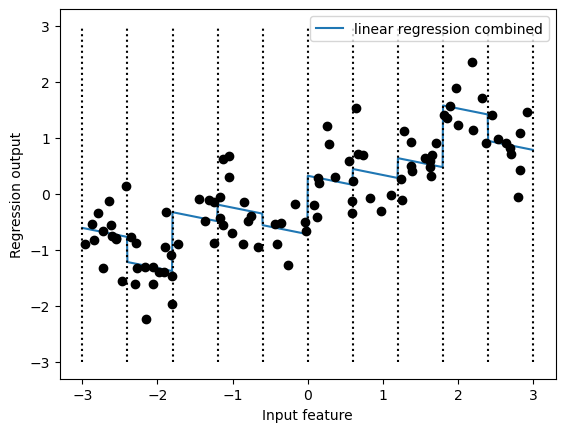

In [40]:
reg = LinearRegression().fit(x_combined, y)

line_combined = np.hstack([line, line_binned])
plt.plot(line, reg.predict(line_combined), label='linear regression combined')

for bib in bins:
    plt.plot([bin, bin], [-3, 3], ':', c='k')
    
plt.legend(loc='best')
plt.ylabel('Regression output')
plt.xlabel('Input feature')
plt.plot(x[:, 0], y, 'o', c='')

In [42]:
x_product = np.hstack([x_binned, x * x_binned])
print(x_product.shape)

(100, 20)


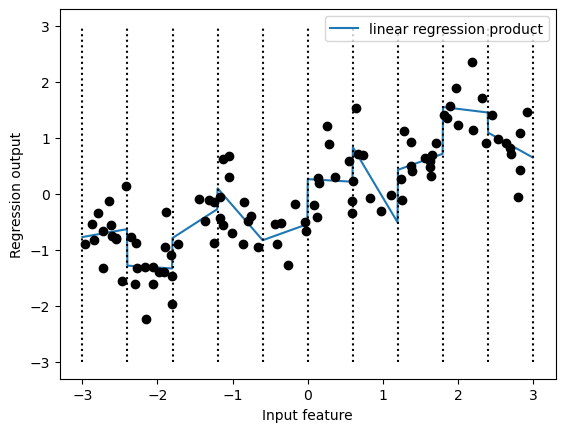

In [45]:
reg = LinearRegression().fit(x_product, y)

line_product = np.hstack([line_binned, line * line_binned])
plt.plot(line, reg.predict(line_product), label='linear regression product')

for bin in bins:
    plt.plot([bin, bin], [-3, 3], ':', c='k')

plt.plot(x[:, 0], y, 'o', c='k')
plt.ylabel('Regression output')
plt.xlabel('Input feature')
plt.legend(loc='best')

In [14]:
from sklearn.preprocessing import PolynomialFeatures

# include polynomials up to x ** 10
# the default "include_bias=True" adds a feature that's constantly 1
poly = PolynomialFeatures(degree=10, include_bias=False)
poly.fit(x)
x_poly = poly.transform(x)

print('x_poly.shape: {}'.format(x_poly.shape))

x_poly.shape: (1000, 285)


In [48]:
print('Entries of x:\n{}'.format(x[:5]))
print('Entries of x_poly:\n{}'.format(x_poly[:5]))

Entries of x:
[[-0.75275929]
 [ 2.70428584]
 [ 1.39196365]
 [ 0.59195091]
 [-2.06388816]]
Entries of x_poly:
[[-7.52759287e-01  5.66646544e-01 -4.26548448e-01  3.21088306e-01
  -2.41702204e-01  1.81943579e-01 -1.36959719e-01  1.03097700e-01
  -7.76077513e-02  5.84199555e-02]
 [ 2.70428584e+00  7.31316190e+00  1.97768801e+01  5.34823369e+01
   1.44631526e+02  3.91124988e+02  1.05771377e+03  2.86036036e+03
   7.73523202e+03  2.09182784e+04]
 [ 1.39196365e+00  1.93756281e+00  2.69701700e+00  3.75414962e+00
   5.22563982e+00  7.27390068e+00  1.01250053e+01  1.40936394e+01
   1.96178338e+01  2.73073115e+01]
 [ 5.91950905e-01  3.50405874e-01  2.07423074e-01  1.22784277e-01
   7.26822637e-02  4.30243318e-02  2.54682921e-02  1.50759786e-02
   8.92423917e-03  5.28271146e-03]
 [-2.06388816e+00  4.25963433e+00 -8.79140884e+00  1.81444846e+01
  -3.74481869e+01  7.72888694e+01 -1.59515582e+02  3.29222321e+02
  -6.79478050e+02  1.40236670e+03]]


In [50]:
print('Polynomial featue names:\n{}'.format(poly.get_feature_names_out()))

Polynomial featue names:
['x0' 'x0^2' 'x0^3' 'x0^4' 'x0^5' 'x0^6' 'x0^7' 'x0^8' 'x0^9' 'x0^10']


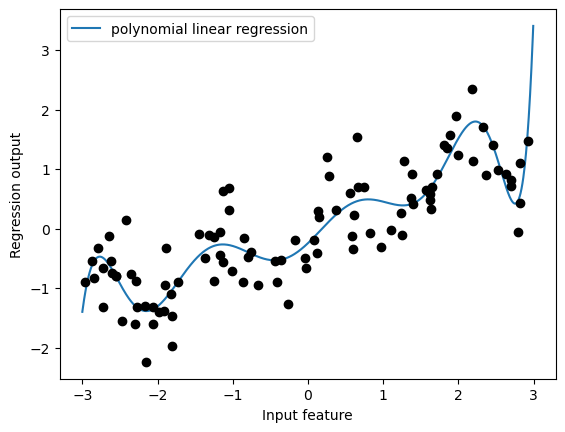

In [51]:
reg = LinearRegression().fit(x_poly, y)

line_poly = poly.transform(line)
plt.plot(line, reg.predict(line_poly), label='polynomial linear regression')
plt.plot(x[:, 0], y, 'o', c='k')
plt.ylabel('Regression output')
plt.xlabel('Input feature')
plt.legend(loc='best')

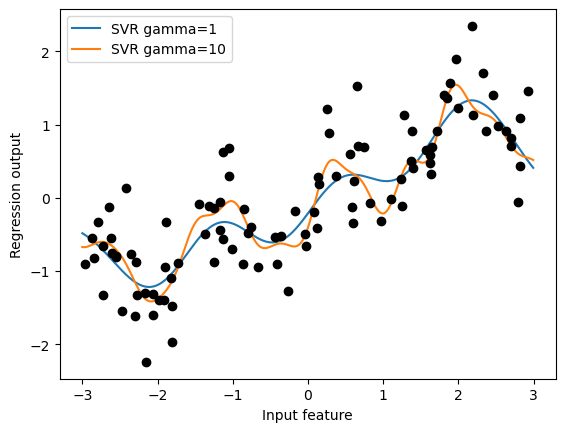

In [53]:
from sklearn.svm import SVR

for gamma in [1, 10]:
    svr = SVR(gamma=gamma).fit(x, y)
    plt.plot(line, svr.predict(line), label='SVR gamma={}'.format(gamma))

plt.plot(x[:, 0], y, 'o', c='k')
plt.ylabel('Regression output')
plt.xlabel('Input feature')
plt.legend(loc='best')

In [15]:
# from sklearn.datasets import load_boston
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

boston = fetch_california_housing()
x_train, x_test, y_train, y_test = train_test_split(
    boston.data, boston.target, random_state=0)

# rescale data
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.fit_transform(x_test)

poly = PolynomialFeatures(degree=2).fit(x_train_scaled)
x_train_poly = poly.transform(x_train_scaled)
x_test_poly  = poly.transform(x_test_scaled)
print('x_train shape: {}'.format(x_train.shape))
print('x_train_poly shape: {}'.format(x_train_poly.shape))

x_train shape: (15480, 8)
x_train_poly shape: (15480, 45)


In [62]:
print('Polynomial feature names:\n{}'.format(
        poly.get_feature_names_out()))

Polynomial feature names:
['1' 'x0' 'x1' 'x2' 'x3' 'x4' 'x5' 'x6' 'x7' 'x0^2' 'x0 x1' 'x0 x2'
 'x0 x3' 'x0 x4' 'x0 x5' 'x0 x6' 'x0 x7' 'x1^2' 'x1 x2' 'x1 x3' 'x1 x4'
 'x1 x5' 'x1 x6' 'x1 x7' 'x2^2' 'x2 x3' 'x2 x4' 'x2 x5' 'x2 x6' 'x2 x7'
 'x3^2' 'x3 x4' 'x3 x5' 'x3 x6' 'x3 x7' 'x4^2' 'x4 x5' 'x4 x6' 'x4 x7'
 'x5^2' 'x5 x6' 'x5 x7' 'x6^2' 'x6 x7' 'x7^2']


In [64]:
from sklearn.linear_model import Ridge
ridge = Ridge().fit(x_train_scaled, y_train)
print('Score without interactions: {:.3f}'.format(
    ridge.score(x_test_scaled, y_test)))
ridge = Ridge().fit(x_train_poly, y_train)
print('Score with interactoins: {:.3f}'.format(
    ridge.score(x_test_poly, y_test)))

Score without interactions: 0.573
Score with interactoins: 0.596


## Univariate Nonlinear Trnasformations

In [4]:
rnd = np.random.RandomState(0)
x_org = rnd.normal(size=(1000, 3))
w = rnd.normal(size=3)

x = rnd.poisson(10 * np.exp(x_org))
y = np.dot(x_org, w)

print('Number of feature appearances:\n{}'.format(np.bincount(x[:, 0])))

Number of feature appearances:
[28 38 68 48 61 59 45 56 37 40 35 34 36 26 23 26 27 21 23 23 18 21 10  9
 17  9  7 14 12  7  3  8  4  5  5  3  4  2  4  1  1  3  2  5  3  8  2  5
  2  1  2  3  3  2  2  3  3  0  1  2  1  0  0  3  1  0  0  0  1  3  0  1
  0  2  0  1  1  0  0  0  0  1  0  0  2  2  0  1  1  0  0  0  0  1  1  0
  0  0  0  0  0  0  1  0  0  0  0  0  1  1  0  0  1  0  0  0  0  0  0  0
  1  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1]


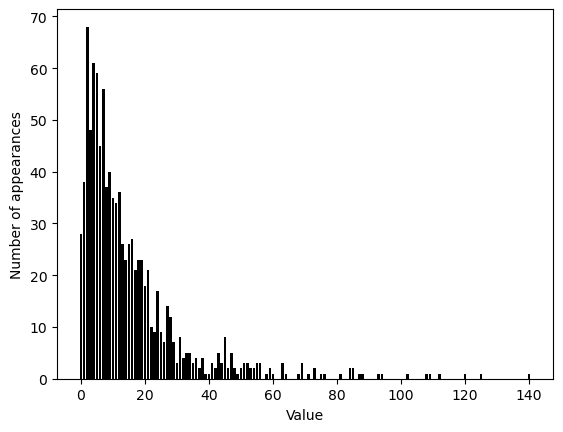

In [12]:
bins = np.bincount(x[:, 0])
plt.bar(range(len(bins)), bins, color='k')
plt.ylabel('Number of appearances')
plt.xlabel('Value')
plt.show()

In [16]:
from sklearn.linear_model import Ridge
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)
score = Ridge().fit(x_train, y_train).score(x_test, y_test)
print('Test score: {:.3f}'.format(score))

Test score: 0.622


Text(0.5, 0, 'Value')

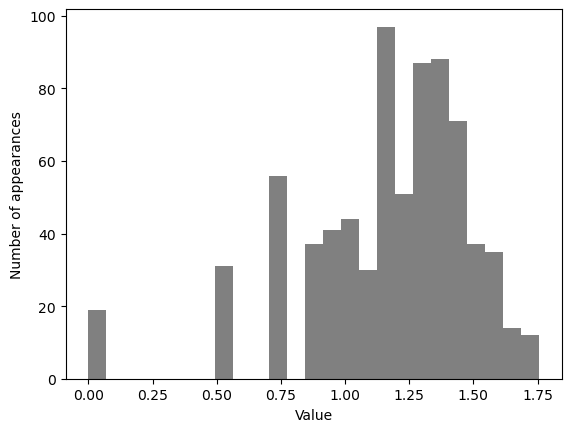

In [31]:
x_train_log = np.log(x_train + 1)
x_test_log  = np.log(x_test + 1)

plt.hist(np.log(x_train_log[:, 0] + 1), bins=25, color='gray')
plt.ylabel('Number of appearances')
plt.xlabel('Value')


In [33]:
score = Ridge().fit(x_train_log, y_train).score(x_test_log, y_test)
print('Test score: {:.3f}'.format(score))

Test score: 0.875
